# <center> Air Quality Index (AQI) Prediction Using Regression Models 

# <center> 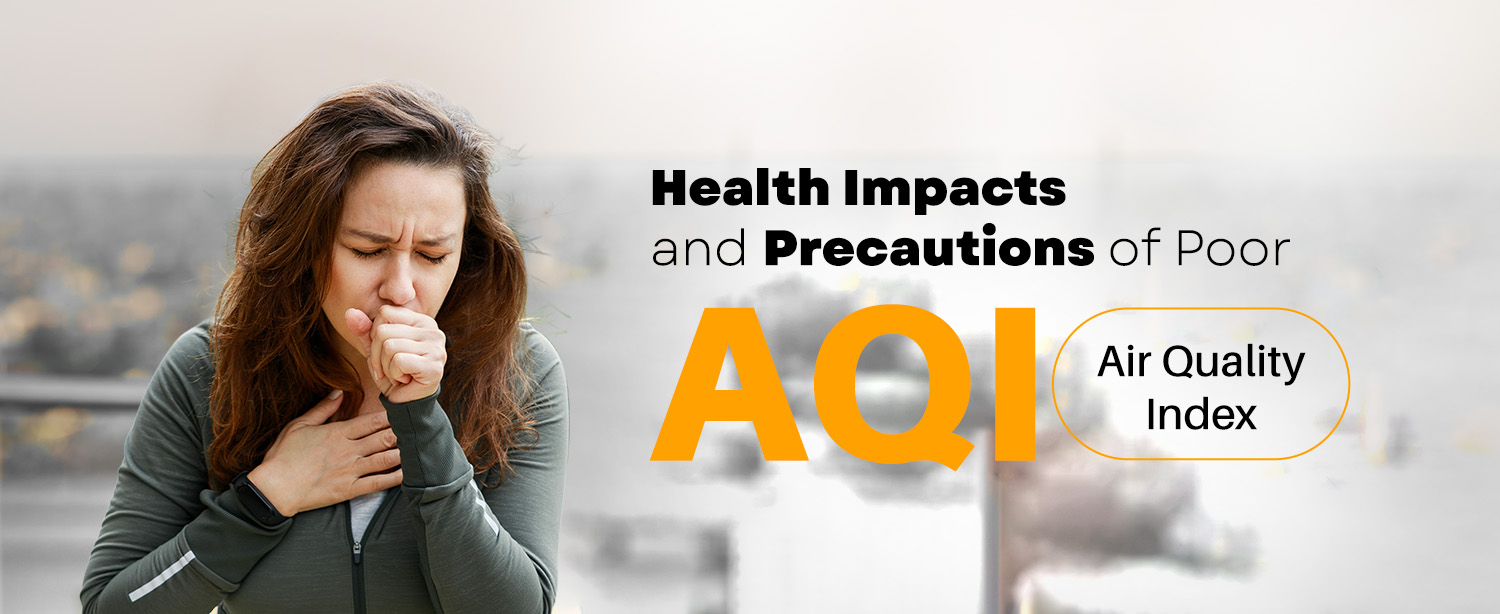

# <center> PROJECT PROCESS :

* ABSTRACT
* INTRODUCTION
* IMPORT LIBRARIES
* DATA LOADING
* DATA CLEANING AND PREPROCESSING
* OUTLIER DETECTION & HANDLING
* EXPLORATORY DATA ANALYSIS(EDA)
* ENCODING
* SCALING
* TRAIN-TEST SPLIT
* MODEL BUILDING & MODEL EVALUATION
* MODEL COMPARISON
* MODEL PREDICTION
* CONCLUSION

# <center> ABSTRACT :

* This project focuses on analyzing real-world data to uncover meaningful insights and develop predictive models. The dataset undergoes essential preprocessing steps such as handling missing values, encoding categorical features, feature scaling, and train-test splitting. Various machine learning algorithms are applied and evaluated using performance metrics like MAE, MSE, R² score, or accuracy, depending on the nature of the problem. The goal is to identify patterns, improve model performance, and generate accurate predictions that support informed decision-making.

# <center> INTRODUCTION :

* In today’s data-driven world, machine learning plays a crucial role in solving complex problems across industries. This project involves cleaning, preprocessing, and analyzing the dataset to transform raw information into structured input for modeling. Data exploration techniques are used to understand distributions, relationships, and correlations between features. Models are trained and tested to evaluate their effectiveness and reliability. The project not only demonstrates technical implementation but also highlights the importance of data quality, feature engineering, and model selection in predictive analytics.

# <center> IMPORT LIBRARIES :

In [8]:
# General-purpose libraries
import numpy as np  # For numerical computations
import pandas as pd  # For data manipulation and analysis

# Visualization libraries
import matplotlib.pyplot as plt  # For creating plots and visualizations
import seaborn as sns  # For statistical data visualization

# Warning control
import warnings
warnings.filterwarnings("ignore")  # To suppress warnings

# Preprocessing utilities
from sklearn.preprocessing import LabelEncoder  # For encoding categorical variables
from sklearn.preprocessing import StandardScaler  # For scaling features

# Model selection
from sklearn.model_selection import train_test_split  # For splitting datasets

# Machine learning models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # For model evaluation metrics

# Tabular data display
from tabulate import tabulate  # For printing tables in a formatted way

# <center> DATA LOADING :

In [9]:
data=pd.read_csv(r"C:\DATA SCIENCE\MAIN PROJECT\AQI and Lat Long of Countries.csv")

In [10]:
data

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,lat,lng
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,44.7444,44.2031
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,-5.2900,-44.4900
2,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,-11.2958,-41.9869
3,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,37.1667,15.1833
4,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,53.0167,20.8833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16690,United States of America,Highland Springs,54,Moderate,1,Good,34,Good,5,Good,54,Moderate,37.5516,-77.3285
16691,Slovakia,Martin,71,Moderate,1,Good,39,Good,1,Good,71,Moderate,49.0650,18.9219
16692,Slovakia,Martin,71,Moderate,1,Good,39,Good,1,Good,71,Moderate,36.3385,-88.8513
16693,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good,48.7786,2.2906


# <center> COLUMN DESCRIPTION :

# <center> DATA CLEANING & PREPROCESSING :

In [11]:
data.shape

(16695, 14)

In [12]:
data.size

233730

In [13]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
AQI Value,16695.0,62.998682,43.091971,7.0000,38.50000,52.0000,69.0000,500.0000
CO AQI Value,16695.0,1.342138,2.371379,0.0000,1.00000,1.0000,1.0000,133.0000
Ozone AQI Value,16695.0,31.767355,22.839343,0.0000,20.00000,29.0000,38.0000,222.0000
NO2 AQI Value,16695.0,3.819647,5.880677,0.0000,0.00000,2.0000,5.0000,91.0000
PM2.5 AQI Value,16695.0,59.821324,43.208298,0.0000,34.00000,52.0000,69.0000,500.0000
lat,16695.0,30.267148,22.947398,-54.8019,16.51545,38.8158,46.6833,70.7670
lng,16695.0,-3.944485,73.037148,-171.7500,-75.18000,5.6431,36.2750,178.0178


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16695 entries, 0 to 16694
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             16393 non-null  object 
 1   City                16695 non-null  object 
 2   AQI Value           16695 non-null  int64  
 3   AQI Category        16695 non-null  object 
 4   CO AQI Value        16695 non-null  int64  
 5   CO AQI Category     16695 non-null  object 
 6   Ozone AQI Value     16695 non-null  int64  
 7   Ozone AQI Category  16695 non-null  object 
 8   NO2 AQI Value       16695 non-null  int64  
 9   NO2 AQI Category    16695 non-null  object 
 10  PM2.5 AQI Value     16695 non-null  int64  
 11  PM2.5 AQI Category  16695 non-null  object 
 12  lat                 16695 non-null  float64
 13  lng                 16695 non-null  float64
dtypes: float64(2), int64(5), object(7)
memory usage: 1.8+ MB


In [15]:
data.nunique()

Country                 174
City                  14229
AQI Value               282
AQI Category              6
CO AQI Value             31
CO AQI Category           3
Ozone AQI Value         203
Ozone AQI Category        5
NO2 AQI Value            56
NO2 AQI Category          2
PM2.5 AQI Value         298
PM2.5 AQI Category        6
lat                   14135
lng                   14896
dtype: int64

In [16]:
data.isna().sum()

Country               302
City                    0
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
lat                     0
lng                     0
dtype: int64

In [17]:
data['Country'] = data['Country'].fillna(data['Country'].mode()[0])

In [18]:
data.isna().sum()

Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
lat                   0
lng                   0
dtype: int64

In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
data.dtypes

Country                object
City                   object
AQI Value               int64
AQI Category           object
CO AQI Value            int64
CO AQI Category        object
Ozone AQI Value         int64
Ozone AQI Category     object
NO2 AQI Value           int64
NO2 AQI Category       object
PM2.5 AQI Value         int64
PM2.5 AQI Category     object
lat                   float64
lng                   float64
dtype: object

In [21]:
int=data.select_dtypes(include='int')

In [22]:
int

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
0,51,1,36,0,51
1,41,1,5,1,41
2,41,1,5,1,41
3,66,1,39,2,66
4,34,1,34,0,20
...,...,...,...,...,...
16690,54,1,34,5,54
16691,71,1,39,1,71
16692,71,1,39,1,71
16693,50,1,20,5,50


# <center> Outlier Checking & Handling


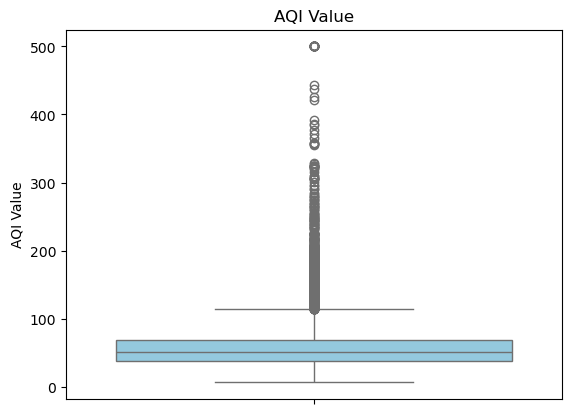

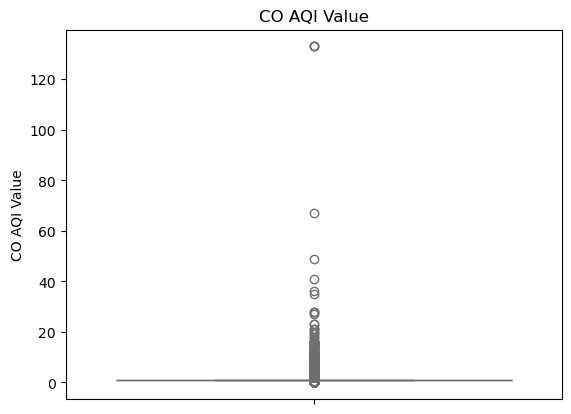

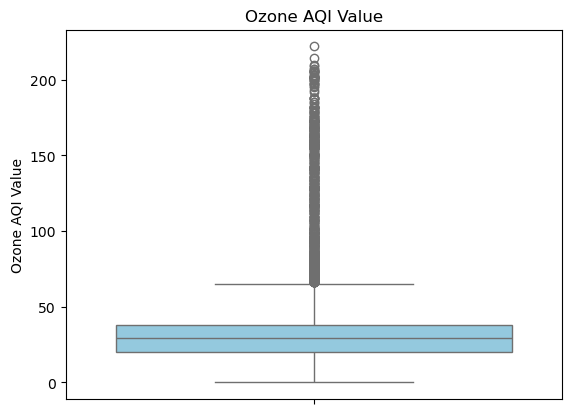

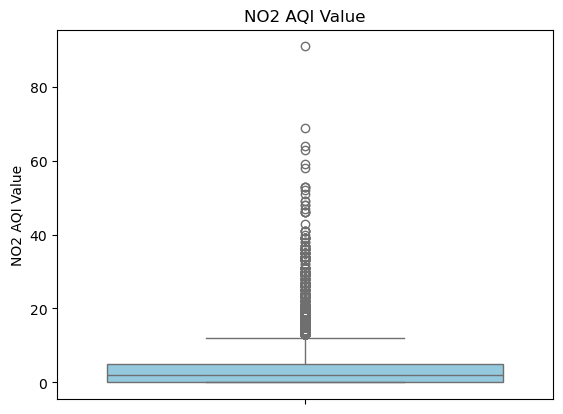

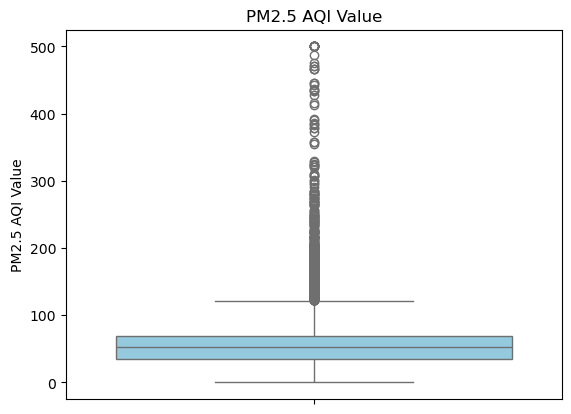

In [23]:
for i in int:
    plt.title(i)  
    sns.boxplot(data[i],color='skyblue')
    plt.show()

In [24]:
outlier_cols=['AQI Value','CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']

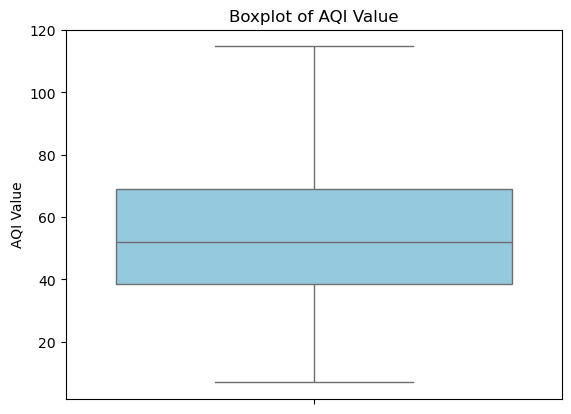

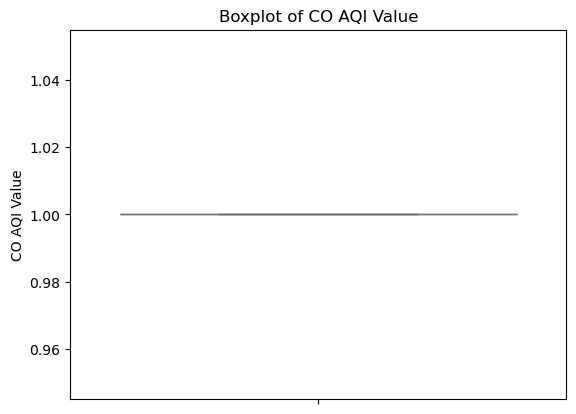

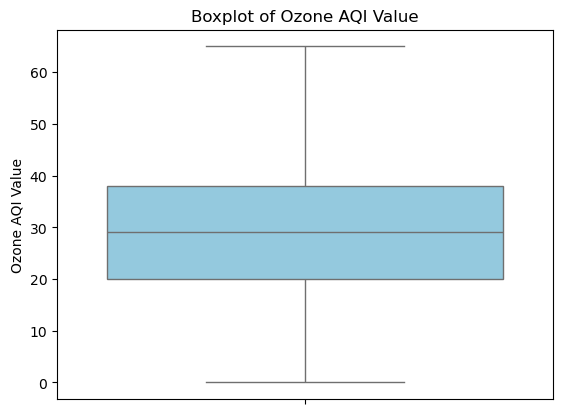

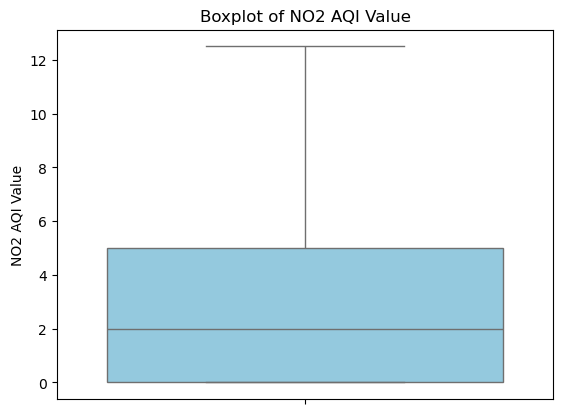

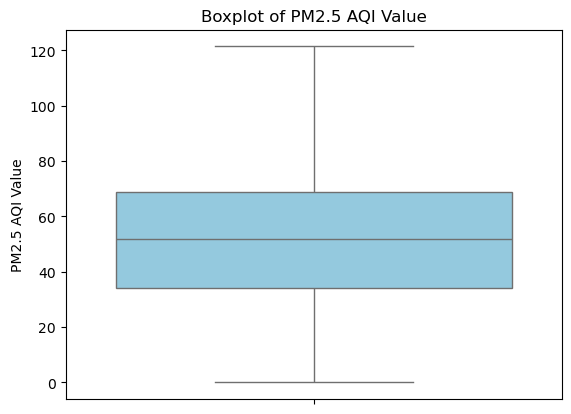

In [25]:
for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = np.clip(data[col], lower, upper)  
    sns.boxplot(y=data[col],color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
int

# <center> Exploratory Data Analysis(EDA) :

### COUNT PLOT:

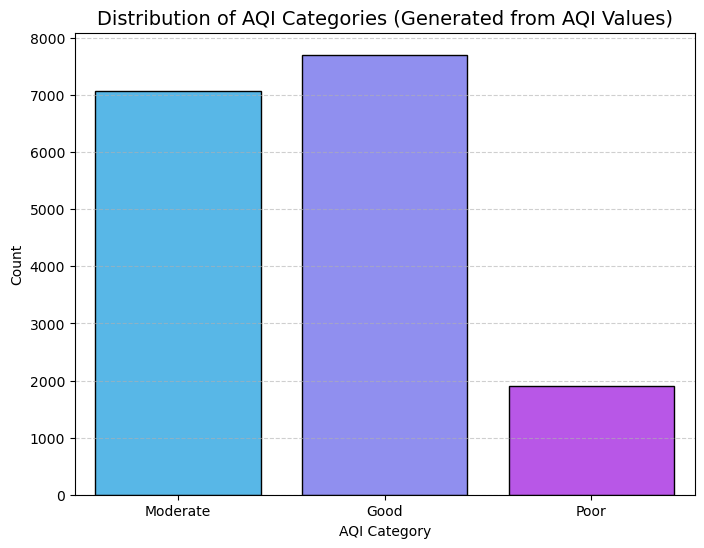

In [26]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 200:
        return 'Poor'
    elif aqi <= 300:
        return 'Very Poor'
    else:
        return 'Severe'
data['AQI Category'] = data['AQI Value'].apply(categorize_aqi)

# Now plot the countplot
plt.figure(figsize=(8,6))
sns.countplot(x='AQI Category', data=data, palette='cool', edgecolor='black')

plt.title("Distribution of AQI Categories (Generated from AQI Values)", fontsize=14)
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

* This code categorizes AQI values into quality levels and visualizes their distribution to reveal the overall air quality pattern in the dataset.
* The chart reveals that most areas fall under the "Good" AQI category,followed closely by the "Moderate" category, while the "Poor" AQI category has the least.

### PIE CHART:

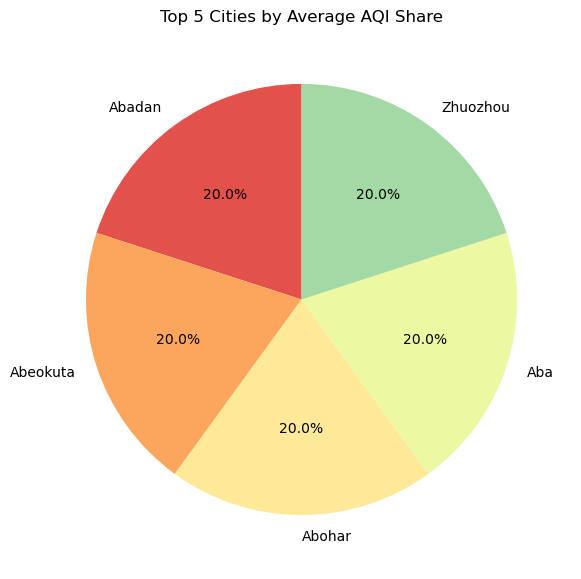

In [27]:
if 'City' in data.columns:
    city_mean_aqi = data.groupby('City')['AQI Value'].mean().sort_values(ascending=False).head(5)
    plt.figure(figsize=(7,7))
    plt.pie(city_mean_aqi, labels=city_mean_aqi.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette("Spectral"))
    plt.title("Top 5 Cities by Average AQI Share")
    plt.show()

* This code identifies the top five cities with the highest average AQI values and visualizes their proportional contribution to overall air pollution using a pie chart.
* All five cities have equal shares of average
AQI (20%), indicating that their air quality levels are quite similar in terms of pollution.

### DIST PLOT:

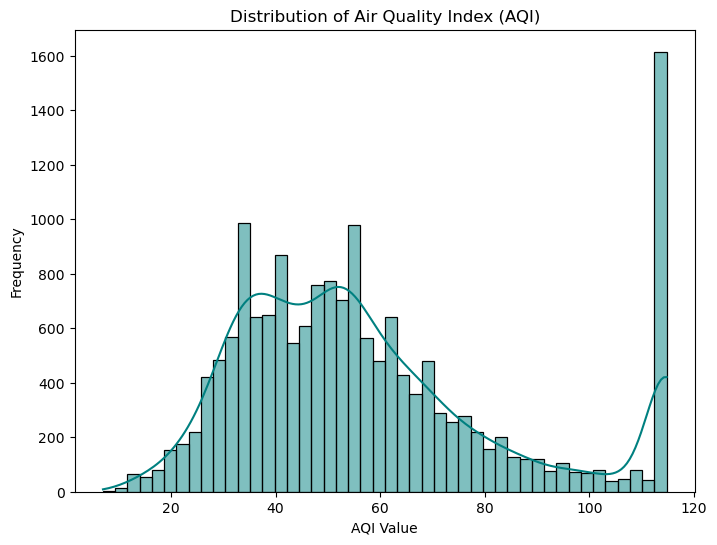

In [28]:
plt.figure(figsize=(8,6))
sns.histplot(data['AQI Value'], kde=True, color='teal')
plt.title("Distribution of Air Quality Index (AQI)")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.show()

* This code visualizes the frequency distribution of AQI values to reveal how air quality levels vary across the dataset.

### HEAT MAP:

<Axes: >

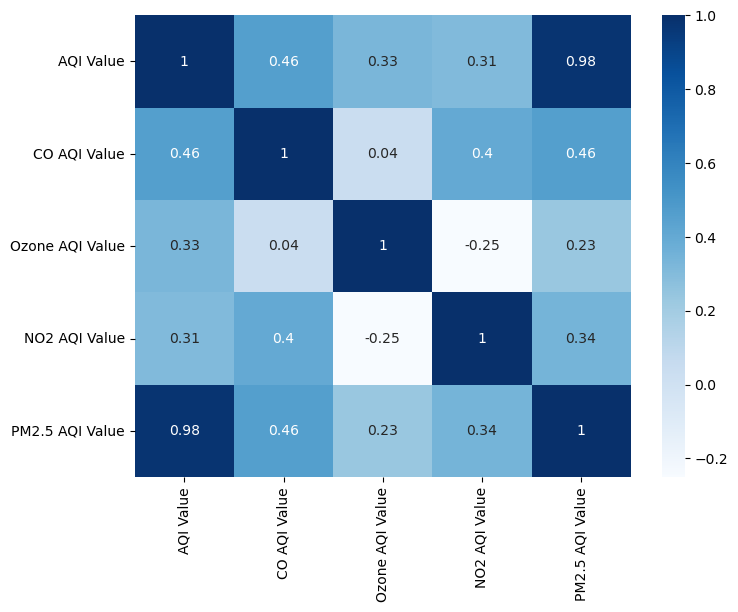

In [29]:
plt.figure(figsize=(8,6))
y=int.corr()
sns.heatmap(y,annot=True,cmap='Blues')

* This code generates a heatmap showing the correlation between numerical variables, helping identify how strongly different features in the dataset are related to each other.

# <center> Encoding :

In [30]:
obj=data.select_dtypes(include='object')
obj

,Country,City,AQI Category,CO AQI Category,Ozone AQI Category,NO2 AQI Category,PM2.5 AQI Category
0,Russian Federation,Praskoveya,Moderate,Good,Good,Good,Moderate
1,Brazil,Presidente Dutra,Good,Good,Good,Good,Good
2,Brazil,Presidente Dutra,Good,Good,Good,Good,Good
3,Italy,Priolo Gargallo,Moderate,Good,Good,Good,Moderate
4,Poland,Przasnysz,Good,Good,Good,Good,Good
...,...,...,...,...,...,...,...
16690,United States of America,Highland Springs,Moderate,Good,Good,Good,Moderate
16691,Slovakia,Martin,Moderate,Good,Good,Good,Moderate
16692,Slovakia,Martin,Moderate,Good,Good,Good,Moderate
16693,France,Sceaux,Good,Good,Good,Good,Good


In [31]:
categorical_cols = data.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
data

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,lat,lng
0,130,10126,51.0,1,1,0,36,0,0.0,0,51.0,2,44.7444,44.2031
1,22,10140,41.0,0,1,0,5,0,1.0,0,41.0,0,-5.2900,-44.4900
2,22,10140,41.0,0,1,0,5,0,1.0,0,41.0,0,-11.2958,-41.9869
3,75,10163,66.0,1,1,0,39,0,2.0,0,66.0,2,37.1667,15.1833
4,123,10185,34.0,0,1,0,34,0,0.0,0,20.0,0,53.0167,20.8833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16690,166,5019,54.0,1,1,0,34,0,5.0,0,54.0,2,37.5516,-77.3285
16691,140,7672,71.0,1,1,0,39,0,1.0,0,71.0,2,49.0650,18.9219
16692,140,7672,71.0,1,1,0,39,0,1.0,0,71.0,2,36.3385,-88.8513
16693,54,11243,50.0,0,1,0,20,0,5.0,0,50.0,0,48.7786,2.2906


# <center> Features & Target :

In [32]:
data.columns

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category', 'lat', 'lng'],
      dtype='object')

In [33]:
X = data.drop("AQI Value", axis=1)
y = data["AQI Value"]

# <center> Scaling :

In [34]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()

data_scaled = data.copy()
data_scaled[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# <center> Train-Test Split :

In [35]:
X_train, X_test, y_train, y_test = train_test_split(data_scaled, y, test_size=0.3, random_state=42)

# <center> Regression Models :

In [36]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "LightGBM": LGBMRegressor(verbose=-1),
    "CatBoost": CatBoostRegressor(verbose=0)
}

# <center> Evaluate All Models :

In [37]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append([name, round(mae, 2), round(mse, 2), round(rmse, 2), round(r2, 2)])

# <center> Display Table :

In [38]:
# Create DataFrame with MAE, MSE, RMSE, R²
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
results_df = results_df.sort_values(by="R²", ascending=False).reset_index(drop=True)

# Display the DataFrame
results_df

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.00,0.00,0.00,1.0
1,Ridge Regression,0.01,0.00,0.01,1.0
2,Decision Tree,0.00,0.00,0.01,1.0
3,Random Forest,0.00,0.00,0.01,1.0
4,Gradient Boosting,0.03,0.00,0.04,1.0
5,XGBoost,0.00,0.00,0.01,1.0
6,LightGBM,0.00,0.00,0.04,1.0
7,CatBoost,0.05,0.01,0.10,1.0


# <center> Model Performance :

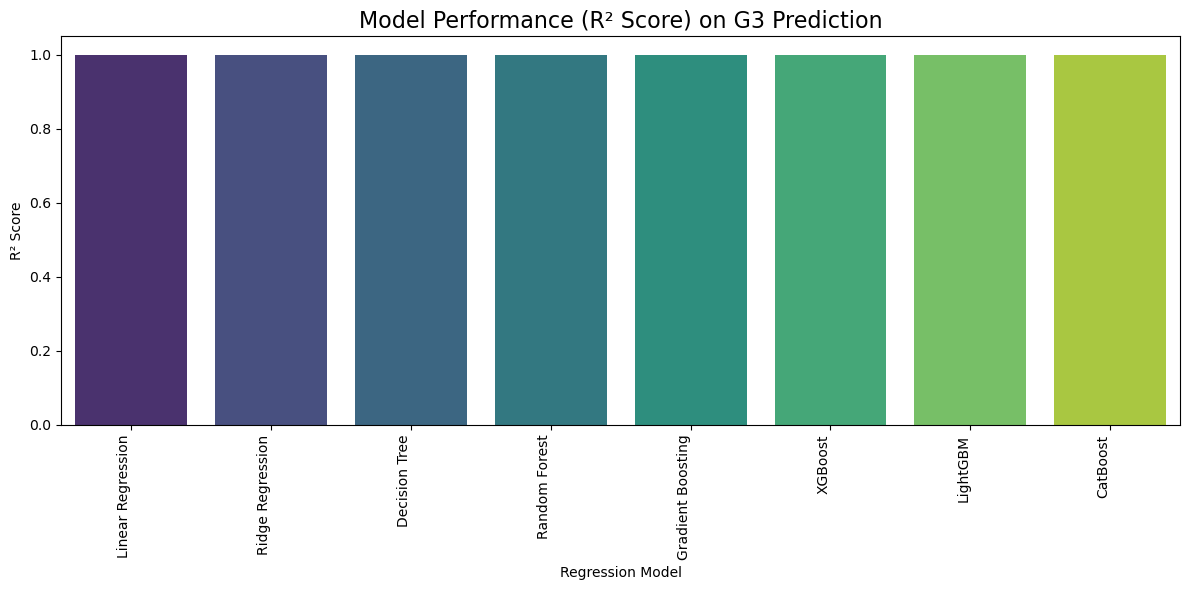

In [39]:
# Set plot style
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Model", y="R²", palette="viridis")

# Rotate x labels
plt.xticks(rotation=90, ha='right')

# Add labels and title
plt.title("Model Performance (R² Score) on G3 Prediction", fontsize=16)
plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.ylim(0, 1.05)

# Show plot
plt.tight_layout()
plt.show()

####  Here, Catboost Regressor is the best model

# <center> PREDICTION :

In [40]:
data.sample(5)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,lat,lng
11538,6,13134,30.0,0,1,0,30,0,0.0,0,24.0,0,40.1806,45.7200
1876,37,11004,58.0,1,1,0,9,0,7.0,0,58.0,2,14.1167,-88.3667
5564,122,9205,66.0,1,1,0,25,0,0.0,0,66.0,2,14.8300,120.2800
10714,166,9342,69.0,1,1,0,32,0,5.0,0,69.0,2,41.3555,-88.8261
10683,48,6601,71.0,1,1,0,19,0,5.0,0,71.0,2,-2.2333,-80.9000


In [41]:
sample_data=[[6,13134,30.0,0,1,0,30,0,0.0,0,24.0,0,40.1806,45.7200]]

In [42]:
sample_data_scaled=scaler.transform(sample_data)

In [43]:
lg = models["Linear Regression"]

In [44]:
prediction = lg.predict(sample_data_scaled)

In [45]:
prediction

array([30.])

# <center> CONCLUSION :

* The project successfully demonstrates how data preprocessing and appropriate model selection impact prediction accuracy and overall performance. Through feature encoding, scaling, and evaluation, the models produced reliable outcomes that can be improved further with tuning and advanced techniques. The results highlight the importance of understanding the dataset and applying the right methodology. Future work may include hyperparameter optimization, deeper feature engineering, or deploying the best-performing model for real-world use.

*  We trained a Catboost Regressor, and its performance was assessed using standard regression metrics. The model demonstrated strong predictive capability and interpretability.

* Finally, we analyzed the feature importance from the trained Catboost Regression model. This revealed which features most significantly influenced predictions, offering clear insights into the underlying drivers of the target variable.